# CETESB - Limpeza, Modelagem e Análises Essenciais

- carregar a base com fallback para cache local;
- limpar e padronizar variáveis-chave;
- reconstruir grupos gerais de atividade a partir dos arquivos brutos;
- preservar as atividades específicas em tabela separada;
- gerar bases analíticas e de modelagem;
- produzir estatísticas e gráficos essenciais.


In [1]:
# ------------------------------------------------------------
# 1. Importação de bibliotecas
# ------------------------------------------------------------

# Expressões regulares para limpeza e busca de padrões em texto.
import re

# Utilitário para remover acentos e normalizar strings.
import unicodedata

# Permite tratar texto em memória como se fosse um arquivo.
from io import StringIO

# Facilita o trabalho com caminhos de arquivos e pastas.
from pathlib import Path

# Biblioteca de gráficos.
import matplotlib.pyplot as plt

# Biblioteca principal para manipulação de dados tabulares.
import pandas as pd

# Biblioteca para fazer requisições HTTP à API ArcGIS.
import requests

# Função útil para exibir dataframes de forma amigável no notebook.
from IPython.display import display

# ------------------------------------------------------------
# 2. Configurações visuais e de exibição
# ------------------------------------------------------------

# Define o estilo padrão dos gráficos.
plt.style.use("seaborn-v0_8-whitegrid")

# Aumenta o número máximo de colunas exibidas ao mostrar um dataframe.
pd.set_option("display.max_columns", 120)

# Aumenta o tamanho máximo do conteúdo textual exibido por coluna.
pd.set_option("display.max_colwidth", 140)

# ------------------------------------------------------------
# 3. Configurações gerais do projeto
# ------------------------------------------------------------

# Fuso horário utilizado na conversão das datas.
TIMEZONE = "America/Sao_Paulo"

# Se False, a base local em cache será usada quando existir.
# Se True, os dados serão baixados novamente da API.
REFRESH_FROM_SOURCE = False

# Endpoint da camada ArcGIS que contém os dados das áreas contaminadas.
ARCGIS_LAYER_URL = (
    "https://mapas.semil.sp.gov.br/server/rest/services/"
    "SIGAM/Empreendimento_Contaminacao_SGP/MapServer/1/query"
)

# Mapeamento entre arquivos brutos auxiliares e os nomes dos grupos gerais.
GROUP_FILE_MAP = {
    "contaminantes_comercio.xls": "Comércio",
    "contaminantes_industria.xls": "Indústria",
    "contaminantes_posto_combustivel.xls": "Posto de Gasolina",
    "contaminantes_cemiterio.xls": "Cemitério",
    "contaminantes_disposição_residuos.xls": "Áreas de disposição de Resíduo",
    "contaminantes_acidentes.xls": "Acidentes",
    "contaminantes_desconhecido.xls": "Desconhecido",
    "contaminantes_outras_atividades.xls": "Outros",
}

# Colunas da base original que serão mantidas no projeto.
SELECTED_COLS = [
    "OBJECTID", "NIS", "IdMunSipol", "NomeEmpree", "AtividadeSipol",
    "TipoEmpree", "ClassificacaoAtual", "DataClassificacao", "NomMunicipio",
    "CodIBGE", "Latitude", "Longitude", "GrupoContaminante",
    "CorrecaoGeorref", "LatCorrigida", "LonCorrigida", "DatAtualiza",
    "FonteContaminacao", "MeiosImpactados", "MedidasEmergenciais",
    "MedidasRemediacao", "DesEndereco", "CEP", "nomUGRHI", "Sigla_DG",
    "flag_postos",
]

# Valores de preenchimento para campos ausentes.
FILL_MAP = {
    "IdMunSipol": "desconhecido",
    "NomeEmpree": "desconhecido",
    "AtividadeSipol": "desconhecido",
    "TipoEmpree": "desconhecido",
    "GrupoContaminante": "desconhecido",
    "FonteContaminacao": "desconhecido",
    "MeiosImpactados": "desconhecido",
    "MedidasEmergenciais": "nenhuma",
}

# Termos que não devem ser quebrados durante o parsing de colunas com "/".
# Exemplo: "Remoção de Solo/Resíduo" deve permanecer como uma única categoria.
PROTECTED = {"Remoção de Solo/Resíduo": "__REMOCAO_SOLO_RESIDUO__"}

# ------------------------------------------------------------
# 4. Resolução de caminhos do projeto
# ------------------------------------------------------------

def resolve_project_dir():
    """
    Procura automaticamente a pasta raiz do projeto,
    verificando o diretório atual e o diretório pai.

    A referência usada é a existência da pasta 'dados-brutos'.
    """
    cwd = Path.cwd().resolve()

    # Verifica o diretório atual e o diretório imediatamente acima.
    for candidate in [cwd, cwd.parent]:
        if (candidate / "dados-brutos").exists():
            return candidate

    # Se não encontrar a pasta esperada, interrompe a execução.
    raise FileNotFoundError("Pasta dados-brutos não encontrada.")

# Define a raiz do projeto.
PROJECT_DIR = resolve_project_dir()

# Pasta onde estão os notebooks e os arquivos exportados.
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"

# Pasta com os arquivos auxiliares brutos por grupo geral.
RAW_GROUP_DIR = PROJECT_DIR / "dados-brutos"

# Caminho para o arquivo Excel com a base bruta em cache.
RAW_CACHE_PATH = PROJECT_DIR / "areas_contaminadas.xlsx"

# Garante que a pasta de notebooks exista.
NOTEBOOK_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 5. Funções auxiliares de exportação, leitura e limpeza
# ------------------------------------------------------------

def safe_to_excel(df, path):
    """
    Salva um dataframe em Excel.
    
    Se o arquivo estiver aberto ou bloqueado, cria automaticamente
    uma cópia com timestamp no nome para evitar erro de escrita.
    """
    path = Path(path)

    try:
        # Tenta salvar normalmente.
        df.to_excel(path, index=False)
        print(f"Salvo: {path.name}")
        return path

    except PermissionError:
        # Se houver bloqueio, cria um nome alternativo com data e hora.
        stamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
        fallback = path.with_stem(f"{path.stem}_{stamp}")

        df.to_excel(fallback, index=False)
        print(f"Arquivo bloqueado: {path.name}. Salvo como {fallback.name}")
        return fallback


def fetch_paginated_features(url, page_size=1000, timeout=30):
    """
    Baixa dados da API ArcGIS em páginas sucessivas até obter todos os registros.
    
    Isso é necessário porque a API costuma limitar o número de linhas por resposta.
    """
    session = requests.Session()

    # Parâmetros básicos da consulta.
    params = {
        "where": "1=1",
        "outFields": "*",
        "returnGeometry": "false",
        "f": "json",
        "resultRecordCount": page_size,
        "resultOffset": 0,
    }

    rows = []

    while True:
        # Faz a requisição para a API.
        response = session.get(url, params=params, timeout=timeout)
        response.raise_for_status()

        payload = response.json()
        features = payload.get("features", [])

        # Se não vierem mais registros, encerra o loop.
        if not features:
            break

        # Extrai o dicionário de atributos de cada feição.
        rows.extend(f["attributes"] for f in features)

        # Se a API informar que não há mais páginas, encerra.
        if not payload.get("exceededTransferLimit"):
            break

        # Caso contrário, avança o offset para buscar a próxima página.
        params["resultOffset"] += page_size

    return pd.DataFrame(rows)


def clean_text(value):
    """
    Limpa e padroniza um valor textual:
    - remove espaços extras
    - converte nulos em None
    """
    if pd.isna(value):
        return None

    value = re.sub(r"\s+", " ", str(value).strip())
    return value or None


def ascii_key(text):
    """
    Converte um texto em uma chave ASCII simples, sem acentos e em minúsculas.
    
    Útil para comparações e regras de normalização.
    """
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    return text.lower().strip()


def dedupe(values):
    """
    Remove duplicatas de uma lista preservando a ordem original.
    """
    seen, out = set(), []

    for value in values:
        if value not in seen:
            seen.add(value)
            out.append(value)

    return out

# ------------------------------------------------------------
# 6. Funções para normalização de AtividadeSipol
# ------------------------------------------------------------

def canonicalize_activity_action(action):
    """
    Padroniza prefixos de ação encontrados em AtividadeSipol.
    
    Exemplo:
    'fab' -> 'fabricação de'
    'comerc' -> 'comércio varejista de'
    """
    raw = clean_text(action)

    if raw is None:
        return None

    key = ascii_key(raw)

    # Mapeamento de abreviações e padrões para formas normalizadas.
    mapping = {
        "fab": "fabricação de",
        "comercio va": "comércio varejista de",
        "comerc va": "comércio varejista de",
        "comerc": "comércio varejista de",
        "comercio atac": "comércio atacadista de",
        "servicos de": "serviços de",
        "servico de": "serviço de",
        "ser": "serviço de",
        "producao de": "produção de",
        "atividade de": "atividade de",
        "atividades de": "atividades de",
        "compra e venda de": "compra e venda de",
        "gestao de": "gestão de",
        "beneficiamento de": "beneficiamento de",
        "extracao de": "extração de",
        "cultivo de": "cultivo de",
        "recuperacao, reciclagem, rerrefino de": "recuperação, reciclagem, rerrefino de",
        "captacao, tratamento e distribuicao de": "captação, tratamento e distribuição de",
        "geracao, producao de": "geração, produção de",
    }

    # Verifica se o texto começa com algum prefixo conhecido.
    for prefix, normalized in mapping.items():
        if key.startswith(prefix):
            return normalized

    # Se não houver regra aplicável, retorna o texto original limpo.
    return raw


def looks_like_action(text):
    """
    Identifica se um trecho textual parece representar uma ação/atividade,
    e não o objeto da atividade.
    """
    return ascii_key(text).startswith((
        "fab", "comerc", "serv", "producao", "atividade de", "atividades de",
        "compra e venda de", "gestao de", "beneficiamento de", "extracao de",
        "cultivo de", "recuperacao, reciclagem, rerrefino de",
        "captacao, tratamento e distribuicao de", "geracao, producao de",
    ))


def normalize_activity(value):
    """
    Normaliza o campo AtividadeSipol reorganizando textos como:
    - 'objeto; ação' -> 'ação objeto'
    - 'objeto, ação' -> 'ação objeto' quando fizer sentido

    Isso ajuda a padronizar descrições que aparecem invertidas na base.
    """
    text = clean_text(value)

    if text is None:
        return None

    # Caso 1: padrão separado por ponto e vírgula.
    if ";" in text:
        left, right = text.split(";", 1)
        left, right = clean_text(left), clean_text(right)

        return left if not right else f"{canonicalize_activity_action(right)} {left}"

    # Caso 2: padrão separado por vírgula.
    if "," in text:
        first_left, first_right = text.split(",", 1)

        # Tenta interpretar o trecho após a primeira vírgula como ação.
        if first_right and looks_like_action(first_right):
            return f"{canonicalize_activity_action(first_right)} {clean_text(first_left)}"

        # Se não funcionar, tenta com a última vírgula.
        last_left, last_right = text.rsplit(",", 1)
        if last_right and looks_like_action(last_right):
            return f"{canonicalize_activity_action(last_right)} {clean_text(last_left)}"

    # Se nenhum padrão especial for identificado, retorna o texto original limpo.
    return text


In [2]:
def split_multivalue(value, sep="/", protected=None):
    """
    Divide um texto com múltiplos valores em uma lista, usando um separador.
    
    Exemplo:
    "A/B/C" -> ["A", "B", "C"]

    O parâmetro 'protected' permite preservar expressões compostas que contêm
    o separador, evitando que sejam quebradas incorretamente.
    """
    # Limpa o texto de entrada.
    text = clean_text(value)

    # Se o valor estiver vazio ou nulo, retorna lista vazia.
    if text is None:
        return []

    # Garante que protected seja um dicionário, mesmo quando None.
    protected = protected or {}

    # Substitui temporariamente expressões protegidas por placeholders.
    # Isso evita que elas sejam divididas pelo separador.
    for original, placeholder in protected.items():
        text = text.replace(original, placeholder)

    parts = []

    # Divide o texto pelo separador principal.
    for chunk in text.split(sep):
        chunk = clean_text(chunk)

        # Ignora pedaços vazios.
        if not chunk:
            continue

        # Restaura os textos originais protegidos.
        for original, placeholder in protected.items():
            chunk = chunk.replace(placeholder, original)

        parts.append(chunk)

    # Remove duplicatas preservando a ordem original.
    return dedupe(parts)


def slugify(text):
    """
    Converte um texto em um nome seguro para ser usado como nome de coluna.

    Exemplo:
    "Águas Subterrâneas" -> "aguas_subterraneas"
    """
    # Remove acentos e converte para ASCII.
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")

    # Converte para minúsculas e troca caracteres não alfanuméricos por "_".
    text = re.sub(r"[^a-z0-9]+", "_", text.lower()).strip("_")

    # Se o texto ficar vazio, retorna um nome padrão.
    return text or "valor_vazio"


def build_dummy_frame(list_series, prefix, source_col):
    """
    Constrói um dataframe de dummies a partir de uma Series cujos valores são listas.
    
    Também retorna um dataframe de mapeamento contendo:
    - coluna de origem
    - valor original
    - nome da coluna dummy gerada
    """
    # Expande as listas em linhas individuais e remove valores nulos.
    exploded = list_series.explode().dropna()

    # Se não houver valores válidos, retorna dataframes vazios.
    if exploded.empty:
        return (
            pd.DataFrame(index=list_series.index),
            pd.DataFrame(columns=["coluna_origem", "valor_original", "coluna_dummy"])
        )

    # Cria a matriz de dummies:
    # linhas   -> índice original
    # colunas  -> categorias encontradas
    # valores  -> contagem de ocorrência
    dummies = pd.crosstab(exploded.index, exploded).reindex(
        index=list_series.index,
        fill_value=0
    )

    # Converte a matriz para formato binário (0/1).
    dummies = (dummies > 0).astype("int8")

    # Estruturas auxiliares para:
    # - renomear as colunas dummy
    # - montar o dicionário de mapeamento
    # - evitar colisão entre nomes repetidos
    rename_map, mapping_rows, used = {}, [], set()

    # Gera um nome de coluna dummy para cada valor original.
    for original in dummies.columns:
        base = f"{prefix}__{slugify(original)}"
        new = base
        i = 2

        # Se já existir uma coluna com esse nome, adiciona sufixo incremental.
        while new in used:
            new = f"{base}_{i}"
            i += 1

        used.add(new)
        rename_map[original] = new

        # Registra o mapeamento entre valor original e coluna dummy.
        mapping_rows.append({
            "coluna_origem": source_col,
            "valor_original": original,
            "coluna_dummy": new
        })

    # Retorna:
    # 1. dataframe de dummies com nomes padronizados
    # 2. dataframe de mapeamento ordenado pelo nome da dummy
    return (
        dummies.rename(columns=rename_map),
        pd.DataFrame(mapping_rows)
        .sort_values("coluna_dummy")
        .reset_index(drop=True)
    )


def load_group_file(path):
    """
    Lê um arquivo bruto auxiliar que contém a classificação de NIS por grupo geral.

    Tenta primeiro como Excel.
    Se falhar, tenta interpretar como tabela HTML.
    """
    try:
        # Tenta ler diretamente como Excel.
        df = pd.read_excel(path)
    except Exception:
        # Se falhar, lê o conteúdo como HTML e extrai a primeira tabela.
        html = path.read_text(encoding="latin-1", errors="ignore")
        df = pd.read_html(StringIO(html))[0]

    # Padroniza os nomes das colunas removendo espaços extras.
    df.columns = [str(col).strip() for col in df.columns]

    # Alguns arquivos podem ter a primeira linha como cabeçalho real.
    # Se "NIS da Área" não estiver nas colunas, usa a primeira linha como cabeçalho.
    if "NIS da Área" not in df.columns:
        df.columns = df.iloc[0].astype(str).str.strip().tolist()
        df = df.iloc[1:].reset_index(drop=True)

    # Converte a coluna NIS para numérico.
    df["NIS da Área"] = pd.to_numeric(df["NIS da Área"], errors="coerce")

    # Remove linhas sem NIS válido.
    df = df.dropna(subset=["NIS da Área"]).copy()

    # Converte o NIS para inteiro.
    df["NIS da Área"] = df["NIS da Área"].astype("int64")

    return df


def build_group_lookup(group_dir, group_file_map):
    """
    Constrói um lookup NIS -> lista de grupos gerais de atividade
    a partir dos arquivos brutos auxiliares.
    """
    frames = []

    # Percorre cada arquivo e associa os NIS encontrados ao grupo correspondente.
    for file_name, group_name in group_file_map.items():
        group_df = load_group_file(group_dir / file_name)

        frames.append(pd.DataFrame({
            "NIS": group_df["NIS da Área"],
            "grupo_atividade_geral": group_name
        }))

    # Junta todos os arquivos em um único dataframe e remove duplicatas.
    merged = pd.concat(frames, ignore_index=True).drop_duplicates()

    # Agrupa por NIS, reunindo todos os grupos associados em uma lista sem duplicatas.
    return (
        merged.groupby("NIS")["grupo_atividade_geral"]
        .agg(dedupe)
        .rename("grupo_atividade_geral_lista")
    )


def attach_group_heuristics(df):
    """
    Aplica heurísticas para completar ou enriquecer os grupos gerais de atividade
    com base em padrões encontrados em NomeEmpree, AtividadeSipol e flag_postos.
    """
    def has_pattern(row, pattern):
        """
        Verifica se um padrão aparece no nome do empreendimento
        ou na atividade SIPOL.
        """
        nome = clean_text(row["NomeEmpree"]) or ""
        atividade = clean_text(row["AtividadeSipol"]) or ""

        return bool(
            re.search(pattern, nome, flags=re.IGNORECASE)
            or re.search(pattern, atividade, flags=re.IGNORECASE)
        )

    def enrich(row):
        """
        Ajusta a lista de grupos gerais para uma linha específica.
        """
        groups = row["grupo_atividade_geral_lista"]

        # Garante que groups seja uma lista copiável.
        groups = [] if not isinstance(groups, list) else groups.copy()

        # Heurística para identificar postos de gasolina.
        if (
            (pd.notna(row["flag_postos"]) and float(row["flag_postos"]) == 1.0)
            or has_pattern(row, r"\bposto\b")
        ):
            if "Posto de Gasolina" not in groups:
                groups.append("Posto de Gasolina")

        # Heurística para identificar cemitérios.
        if has_pattern(row, r"cemit") and "Cemitério" not in groups:
            groups.append("Cemitério")

        # Heurística para identificar acidentes.
        if has_pattern(row, r"acident") and "Acidentes" not in groups:
            groups.append("Acidentes")

        # Se nenhum grupo tiver sido encontrado, marca como desconhecido.
        return groups if groups else ["Desconhecido"]

    # Aplica a função linha a linha.
    return df.apply(enrich, axis=1)


def plot_heatmap(data, title, figsize=(10, 6), cmap="Blues", fmt="{:.2f}"):
    """
    Plota um heatmap simples com valores anotados dentro das células.
    
    Parâmetros:
    - data: dataframe com os valores a serem plotados
    - title: título do gráfico
    - figsize: tamanho da figura
    - cmap: paleta de cores
    - fmt: formato do texto exibido nas células
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Desenha a matriz de cores.
    im = ax.imshow(data.values, aspect="auto", cmap=cmap)

    # Configura os rótulos do eixo x.
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha="right")

    # Configura os rótulos do eixo y.
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)

    # Define o título do gráfico.
    ax.set_title(title)

    # Escreve os valores dentro de cada célula do heatmap.
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(
                j,
                i,
                fmt.format(data.iloc[i, j]),
                ha="center",
                va="center",
                fontsize=8
            )

    # Adiciona a barra de cores.
    fig.colorbar(im, ax=ax)

    # Ajusta o layout para evitar sobreposição.
    plt.tight_layout()

    # Exibe o gráfico.
    plt.show()


In [3]:
# Verifica se já existe um arquivo local com a base bruta
# e se a configuração atual permite reutilizar esse cache.
if RAW_CACHE_PATH.exists() and not REFRESH_FROM_SOURCE:
    # Se o arquivo existir e não houver pedido de atualização,
    # lê a base diretamente do Excel salvo localmente.
    df_raw = pd.read_excel(RAW_CACHE_PATH)
else:
    # Caso contrário, baixa novamente os dados da fonte ArcGIS.
    df_raw = fetch_paginated_features(ARCGIS_LAYER_URL)

    # Depois de baixar, salva uma cópia local para evitar
    # novas consultas desnecessárias nas próximas execuções.
    safe_to_excel(df_raw, RAW_CACHE_PATH)

# Exibe as primeiras linhas da base para inspeção rápida.
display(df_raw.head())

# Mostra a estrutura geral do dataframe:
# número de linhas, colunas, tipos e valores não nulos.
df_raw.info()


,OBJECTID,NIS,NumSipol,IdMunSipol,NumSipolText,NomeEmpree,AtividadeSipol,OrigemSipol,MigradoAccess,TipoEmpree,ClassificacaoAtual,DataClassificacao,NomMunicipio,CodIBGE,Latitude,Longitude,GrupoContaminante,Contaminante,ContaminanteIngles,EtapaGerenciamento,CorrecaoGeorref,LatCorrigida,LonCorrigida,Sede,DatAtualiza,FonteContaminacao,MeiosImpactados,MedidasEmergenciais,Interv_RUASUB,Interv_RUASUP,Interv_RCA,Interv_RUE,Interv_RUS,Interv_RETO,Interv_RPAF,MedidasRemediacao,MedidasEngenharia,DesEndereco,DesLocalizacao,DesEndeComple,NomBairro,NomDistrito,CEP,nomUGRHI,Sigla_DG,flag_postos
0,1,1,484298.0,100.0,100 - 484298,AUTO POSTO PIRITUBANO LTDA,Combustíveis e lubrificantes para veículos; comércio varejista,V,V,Sem Tipologia Específica,Área Contaminada em Processo de Remediação (ACRe),1225508400000,SÃO PAULO,3550308,-23.489584,-46.729475,COMBUSTÍVEIS AUTOMOTIVOS/SOLVENTES AROMÁTICOS/PAHs,NaN,NaN,NaN,GDec/GDec val. invert.; ate 50m do limite de munic,-23.489584,-46.729475,0,1748629599000,Armazenagem,Águas Subterrâneas/Subsolo (DENTRO),Monitoramento Ambiental,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,Bombeamento e Tratamento/Extração Multifásica,NaN,"AVENIDA RAIMUNDO PEREIRA DE MAGALHAES, 4520","AVENIDA RAIMUNDO PEREIRA DE MAGALHAES, 4520",NaN,NaN,NaN,51452-00,06 - ALTO TIETÊ,ACRe,1.0
1,2,2,1005546.0,100.0,100 - 1005546,CONDOMÍNIO LUMINA PARQUE CLUBE (MARSHALL EMPR. LTDA.),NaN,V,V,NaN,Área Reabilitada para o Uso Declarado (AR),1739462309000,SÃO PAULO,3550308,-23.538077,-46.590618,METAIS/PAHs/Grupo TPH/CONTAMINANTES,NaN,NaN,NaN,GDec/GDec val. invert.; ate 50m do limite de munic,-23.538077,-46.590618,0,1739461641000,Produção,Águas Subterrâneas/Subsolo (DENTRO),NaN,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,Remoção de Solo/Resíduo,NaN,"R. CONSELHEIRO COTEGIPE, 294",NaN,NaN,BELENZINHO,NaN,3058000,06 - ALTO TIETÊ,AR,0.0
2,3,3,1005442.0,373.0,373 - 1005442,"PAULISTA S/A COM., PART. E EMPR.",NaN,V,V,NaN,Área Reabilitada para o Uso Declarado (AR),1447729200000,ITAPEVI,3522505,-23.545686,-46.966062,METAIS,NaN,NaN,NaN,GDec/GDec val. invert.; ate 50m do limite de munic,-23.545686,-46.966062,0,1739461641000,Descartes,Solo Superficial/Águas Subterrâneas (DENTRO),NaN,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,Sem Medidas de Remediação,NaN,"EST. ELIAS ALVES DA COSTA, S/N",NaN,NaN,PARQUE BOA ESPERA,NaN,6675200,06 - ALTO TIETÊ,AR,0.0
3,4,4,226727.0,438.0,438 - 226727,DALLAS AUTO POSTO DE MARÍLIA LTDA,Combustíveis e lubrificantes para veículos; comércio varejista,V,V,Áreas Contaminadas,Área Contaminada sob Investigação (ACI),1742353200000,MARÍLIA,3529005,-22.215234,-49.939638,SOLVENTES AROMÁTICOS/COMBUSTÍVEIS AUTOMOTIVOS,NaN,NaN,NaN,GDec/GDec val. invert.; ate 50m do limite de munic,-22.215234,-49.939638,0,1742914461000,Armazenagem,Subsolo,NaN,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,Extração de Vapores do Solo (SVE),NaN,"AVENIDA VICENTE FERREIRA, 543","AVENIDA VICENTE FERREIRA, 543",NaN,NaN,NaN,17515-000,21 - PEIXE,ACI,1.0
4,5,5,956.0,462.0,462 - 956,MOLINA & DANTAS COMBUSTÍVEIS LTDA,Combustíveis e lubrificantes para veículos; comércio varejista,V,V,Sem Tipologia Específica,Área Contaminada com Risco Confirmado (ACRi),1151722800000,MONTE APRAZÍVEL,3531407,-20.768127,-49.710112,COMBUSTÍVEIS AUTOMOTIVOS/SOLVENTES AROMÁTICOS,NaN,NaN,NaN,GDec/GDec val. invert.; ate 50m do limite de munic,-20.768127,-49.710112,0,1739461641000,Armazenagem,Subsolo,NaN,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,NAO/NAO/NAO/NAO,Sem Medidas de Remediação,NaN,"AVENIDA SANTOS DUMONT, 64","AVENIDA SANTOS DUMONT, 64",NaN,NaN,NaN,15150-000,18 - SÃO JOSÉ DOS DOURADOS,ACRi,1.0


<class 'pandas.DataFrame'>
RangeIndex: 7141 entries, 0 to 7140
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   OBJECTID             7141 non-null   int64  
 1   NIS                  7141 non-null   int64  
 2   NumSipol             7104 non-null   float64
 3   IdMunSipol           7100 non-null   float64
 4   NumSipolText         7100 non-null   str    
 5   NomeEmpree           7104 non-null   str    
 6   AtividadeSipol       5521 non-null   str    
 7   OrigemSipol          7141 non-null   str    
 8   MigradoAccess        7141 non-null   str    
 9   TipoEmpree           5047 non-null   str    
 10  ClassificacaoAtual   7141 non-null   str    
 11  DataClassificacao    7141 non-null   int64  
 12  NomMunicipio         7141 non-null   str    
 13  CodIBGE              7141 non-null   int64  
 14  Latitude             7141 non-null   float64
 15  Longitude            7141 non-null   float64
 16 

In [4]:
# ------------------------------------------------------------
# 1. Construção da base analítica
# ------------------------------------------------------------

# Lê e consolida a informação dos arquivos brutos auxiliares
# para montar um lookup de NIS -> grupo(s) geral(is) de atividade.
group_lookup = build_group_lookup(RAW_GROUP_DIR, GROUP_FILE_MAP)

# Seleciona apenas as colunas relevantes da base bruta.
# A partir daqui, trabalhamos sobre uma cópia para evitar alterar df_raw diretamente.
areas_analitica = df_raw[SELECTED_COLS].copy()

# ------------------------------------------------------------
# 2. Tratamento de valores ausentes
# ------------------------------------------------------------

# Trata IdMunSipol separadamente:
# - se estiver nulo, usa o valor definido em FILL_MAP
# - se for numérico inteiro, converte para string sem casas decimais
# - caso contrário, mantém como string
areas_analitica["IdMunSipol"] = areas_analitica["IdMunSipol"].apply(
    lambda x: FILL_MAP["IdMunSipol"]
    if pd.isna(x)
    else str(int(x)) if float(x).is_integer()
    else str(x)
)

# Preenche nulos das colunas textuais principais com valores padronizados.
for col in [
    "NomeEmpree",
    "AtividadeSipol",
    "TipoEmpree",
    "GrupoContaminante",
    "FonteContaminacao",
    "MeiosImpactados",
]:
    areas_analitica[col] = areas_analitica[col].fillna(FILL_MAP[col])

# Preenche nulos de medidas emergenciais com um valor específico.
areas_analitica["MedidasEmergenciais"] = (
    areas_analitica["MedidasEmergenciais"]
    .fillna(FILL_MAP["MedidasEmergenciais"])
)

# ------------------------------------------------------------
# 3. Conversão das datas
# ------------------------------------------------------------

# As colunas de data estão em epoch milliseconds.
# Aqui elas são convertidas para datetime no fuso de São Paulo
# e ficam armazenadas em novas colunas com sufixo "_dt".
for col in ["DataClassificacao", "DatAtualiza"]:
    areas_analitica[f"{col}_dt"] = (
        pd.to_datetime(
            areas_analitica[col],
            unit="ms",
            utc=True,
            errors="coerce"
        )
        .dt.tz_convert(TIMEZONE)
        .dt.tz_localize(None)
    )

# ------------------------------------------------------------
# 4. Parsing e normalização de colunas textuais
# ------------------------------------------------------------

# Normaliza a descrição da atividade para reduzir variações textuais
# e melhorar a consistência analítica.
areas_analitica["AtividadeSipol_normalizada"] = (
    areas_analitica["AtividadeSipol"]
    .apply(normalize_activity)
)

# Transforma a atividade normalizada em lista.
# Isso mantém o padrão das outras colunas multi-valor.
areas_analitica["AtividadeSipol_lista"] = (
    areas_analitica["AtividadeSipol_normalizada"]
    .apply(lambda x: [x] if clean_text(x) else ["desconhecido"])
)

# Divide os grupos contaminantes em listas usando "/" como separador.
areas_analitica["GrupoContaminante_lista"] = (
    areas_analitica["GrupoContaminante"]
    .apply(lambda x: split_multivalue(x, "/"))
)

# Divide as fontes de contaminação em listas.
areas_analitica["FonteContaminacao_lista"] = (
    areas_analitica["FonteContaminacao"]
    .apply(lambda x: split_multivalue(x, "/"))
)

# Divide os meios impactados em listas.
areas_analitica["MeiosImpactados_lista"] = (
    areas_analitica["MeiosImpactados"]
    .apply(lambda x: split_multivalue(x, "/"))
)

# Divide as medidas emergenciais em listas.
areas_analitica["MedidasEmergenciais_lista"] = (
    areas_analitica["MedidasEmergenciais"]
    .apply(lambda x: split_multivalue(x, "/"))
)

# Divide as medidas de remediação em listas, protegendo termos compostos
# que não devem ser quebrados indevidamente.
areas_analitica["MedidasRemediacao_lista"] = (
    areas_analitica["MedidasRemediacao"]
    .apply(lambda x: split_multivalue(x, "/", PROTECTED))
)

# ------------------------------------------------------------
# 5. Anexação dos grupos gerais de atividade
# ------------------------------------------------------------

# Faz merge com o lookup construído a partir dos arquivos brutos.
# Isso adiciona a coluna de grupos gerais associados ao NIS.
areas_analitica = areas_analitica.merge(group_lookup, on="NIS", how="left")

# Aplica heurísticas complementares para recuperar ou enriquecer
# os grupos gerais quando a informação estiver ausente ou incompleta.
areas_analitica["grupo_atividade_geral_lista"] = (
    attach_group_heuristics(areas_analitica)
)

# Cria uma versão em texto único dos grupos gerais,
# separando múltiplos grupos com " | ".
areas_analitica["grupo_atividade_geral"] = (
    areas_analitica["grupo_atividade_geral_lista"]
    .apply(lambda xs: " | ".join(xs))
)

# Marca se a observação possui mais de um grupo geral associado.
areas_analitica["grupo_atividade_geral_multiplo"] = (
    areas_analitica["grupo_atividade_geral_lista"]
    .apply(lambda xs: len(xs) > 1)
)

# Cria uma versão simplificada do segmento:
# - se houver um único grupo, usa esse grupo
# - se houver múltiplos, marca como "Múltiplo"
areas_analitica["grupo_atividade_segmento"] = (
    areas_analitica["grupo_atividade_geral_lista"]
    .apply(lambda xs: xs[0] if len(xs) == 1 else "Múltiplo")
)

# ------------------------------------------------------------
# 6. Geração das dummies
# ------------------------------------------------------------

# Define quais colunas em formato de lista serão transformadas em dummies.
# Cada tupla contém:
# - nome da coluna lista
# - prefixo das dummies
# - nome da coluna original de referência
dummy_specs = [
    ("grupo_atividade_geral_lista", "grupo_atividade", "grupo_atividade_geral"),
    ("GrupoContaminante_lista", "grupo_contaminante", "GrupoContaminante"),
    ("FonteContaminacao_lista", "fonte_contaminacao", "FonteContaminacao"),
    ("MeiosImpactados_lista", "meio_impactado", "MeiosImpactados"),
    ("MedidasEmergenciais_lista", "medida_emergencial", "MedidasEmergenciais"),
    ("MedidasRemediacao_lista", "medida_remediacao", "MedidasRemediacao"),
]

# Essas listas vão armazenar:
# - os dataframes de dummies
# - os mapeamentos entre valores originais e nomes das colunas dummy
dummy_frames, mapping_frames = [], []

# Gera dummies para cada coluna especificada e acumula os resultados.
for list_col, prefix, source_col in dummy_specs:
    dummies_df, mapping_df = build_dummy_frame(
        areas_analitica[list_col],
        prefix,
        source_col
    )
    dummy_frames.append(dummies_df)
    mapping_frames.append(mapping_df)

# ------------------------------------------------------------
# 7. Construção dos datasets finais
# ------------------------------------------------------------

# Cria a base de modelagem concatenando:
# - a base analítica
# - todas as colunas dummy geradas
#
# A coluna AtividadeSipol_lista é removida para evitar carregar listas
# desnecessárias nesse dataset final.
areas_contaminadas_modelagem = pd.concat(
    [areas_analitica.drop(columns=["AtividadeSipol_lista"], errors="ignore"), *dummy_frames],
    axis=1
).copy()

# Concatena todos os mapeamentos das dummies em um único dicionário.
dicionario_dummies_modelagem = pd.concat(
    mapping_frames,
    ignore_index=True
)

# Cria uma tabela enxuta apenas com as atividades específicas,
# preservando a ligação com a observação por OBJECTID e NIS.
atividades_especificas_df = areas_analitica[
    [
        "OBJECTID",
        "NIS",
        "NomeEmpree",
        "AtividadeSipol",
        "AtividadeSipol_normalizada",
        "grupo_atividade_geral",
        "DataClassificacao_dt",
        "DatAtualiza_dt",
    ]
].copy()

# ------------------------------------------------------------
# 8. Resumo dos datasets gerados
# ------------------------------------------------------------

# Mostra um pequeno resumo com o nome e o shape de cada dataset criado.
display(pd.DataFrame({
    "dataset": [
        "areas_analitica",
        "areas_contaminadas_modelagem",
        "atividades_especificas_df",
        "dicionario_dummies_modelagem",
    ],
    "shape": [
        areas_analitica.shape,
        areas_contaminadas_modelagem.shape,
        atividades_especificas_df.shape,
        dicionario_dummies_modelagem.shape,
    ],
}))

# Exibe a estrutura detalhada da base de modelagem:
# número de linhas, colunas, tipos e memória.
areas_contaminadas_modelagem.info()


,dataset,shape
0,areas_analitica,"(7141, 39)"
1,areas_contaminadas_modelagem,"(7141, 139)"
2,atividades_especificas_df,"(7141, 8)"
3,dicionario_dummies_modelagem,"(101, 3)"


<class 'pandas.DataFrame'>
RangeIndex: 7141 entries, 0 to 7140
Columns: 139 entries, OBJECTID to medida_remediacao__tratamento_termico_in_situ
dtypes: bool(1), datetime64[ms](2), float64(5), int64(5), int8(101), object(6), str(19)
memory usage: 2.7+ MB


In [5]:
# Exporta a base analítica principal para Excel.
# A coluna "AtividadeSipol_lista" é removida porque contém listas,
# o que costuma deixar o arquivo menos amigável para leitura no Excel.
safe_to_excel(
    areas_analitica.drop(columns=["AtividadeSipol_lista"], errors="ignore"),
    NOTEBOOK_DIR / "areas_contaminadas_analitica.xlsx"
)

# Exporta a base de modelagem, que inclui as variáveis dummies
# prontas para análises quantitativas e modelos.
safe_to_excel(
    areas_contaminadas_modelagem,
    NOTEBOOK_DIR / "areas_contaminadas_modelagem.xlsx"
)

# Exporta a tabela com as atividades específicas.
# Essa tabela preserva a atividade detalhada associada a cada observação,
# o que é útil para análises mais desagregadas.
safe_to_excel(
    atividades_especificas_df,
    NOTEBOOK_DIR / "atividades_especificas.xlsx"
)

# Exporta o dicionário das dummies criadas no processo.
# Esse arquivo ajuda a entender qual valor original deu origem
# a cada coluna dummy da base de modelagem.
safe_to_excel(
    dicionario_dummies_modelagem,
    NOTEBOOK_DIR / "dicionario_dummies_modelagem.xlsx"
)


Salvo: areas_contaminadas_analitica.xlsx
Salvo: areas_contaminadas_modelagem.xlsx
Salvo: atividades_especificas.xlsx
Salvo: dicionario_dummies_modelagem.xlsx


WindowsPath('C:/Users/User/Documents/Códigos Github/cetesb-contaminant-study/notebooks/dicionario_dummies_modelagem.xlsx')

## Análises essenciais


In [6]:
# ------------------------------------------------------------
# 1. Auditoria por NIS
# ------------------------------------------------------------

# Ordena a base por NIS e pelas datas relevantes antes de agregar.
# Isso ajuda a manter consistência analítica ao inspecionar a evolução
# de cada área contaminada ao longo do tempo.
nis_audit_df = (
    areas_analitica
    .sort_values(["NIS", "DataClassificacao_dt", "DatAtualiza_dt"])
    .groupby("NIS")
    .agg(
        # Quantidade total de registros associados a cada NIS.
        registros=("OBJECTID", "size"),

        # Número de classificações distintas observadas para o mesmo NIS.
        classificacoes_distintas=("ClassificacaoAtual", "nunique"),

        # Número de grupos gerais distintos associados ao mesmo NIS.
        grupos_gerais_distintos=("grupo_atividade_geral", "nunique"),

        # Primeira data de classificação observada para o NIS.
        primeira_data_classificacao=("DataClassificacao_dt", "min"),

        # Última data de classificação observada para o NIS.
        ultima_data_classificacao=("DataClassificacao_dt", "max"),

        # Data mais recente de atualização do registro.
        ultima_atualizacao=("DatAtualiza_dt", "max"),

        # Quantos municípios distintos aparecem associados ao mesmo NIS.
        municipios_distintos=("NomMunicipio", "nunique"),
    )
    .reset_index()
)

# ------------------------------------------------------------
# 2. Quadro-resumo da base
# ------------------------------------------------------------

# Monta um pequeno painel com métricas gerais da base,
# útil para checagem rápida de cobertura, granularidade e período.
overview_df = pd.DataFrame({
    "métrica": [
        "observações",
        "NIS únicos",
        "NIS com múltiplas observações",
        "NIS com múltiplas classificações",
        "NIS com múltiplos grupos gerais",
        "municípios únicos",
        "intervalo de classificação",
        "intervalo de atualização",
    ],
    "valor": [
        # Número total de linhas da base analítica.
        len(areas_analitica),

        # Quantidade de NIS únicos.
        areas_analitica["NIS"].nunique(),

        # Quantos NIS aparecem mais de uma vez na base.
        int((nis_audit_df["registros"] > 1).sum()),

        # Quantos NIS apresentam mais de uma classificação ao longo do tempo.
        int((nis_audit_df["classificacoes_distintas"] > 1).sum()),

        # Quantos NIS aparecem associados a mais de um grupo geral.
        int((nis_audit_df["grupos_gerais_distintos"] > 1).sum()),

        # Número de municípios distintos presentes na base.
        areas_analitica["NomMunicipio"].nunique(),

        # Intervalo total coberto pelas datas de classificação.
        f"{areas_analitica['DataClassificacao_dt'].min():%Y-%m-%d} -> {areas_analitica['DataClassificacao_dt'].max():%Y-%m-%d}",

        # Intervalo total coberto pelas datas de atualização.
        f"{areas_analitica['DatAtualiza_dt'].min():%Y-%m-%d} -> {areas_analitica['DatAtualiza_dt'].max():%Y-%m-%d}",
    ],
})

# ------------------------------------------------------------
# 3. Tabelas de frequência
# ------------------------------------------------------------

# Frequência dos grupos gerais de atividade.
# Como a coluna é uma lista, usamos explode() para contar cada grupo separadamente.
grupo_freq_df = (
    areas_analitica
    .explode("grupo_atividade_geral_lista")["grupo_atividade_geral_lista"]
    .value_counts()
    .rename_axis("grupo_atividade_geral")
    .reset_index(name="qtd_observacoes")
)

# Calcula o percentual de cada grupo em relação ao total de observações da base.
grupo_freq_df["percentual"] = (
    100 * grupo_freq_df["qtd_observacoes"] / len(areas_analitica)
)

# Frequência das classificações atuais.
classificacao_freq_df = (
    areas_analitica["ClassificacaoAtual"]
    .value_counts()
    .rename_axis("ClassificacaoAtual")
    .reset_index(name="qtd_observacoes")
)

# Frequência dos municípios.
municipio_freq_df = (
    areas_analitica["NomMunicipio"]
    .value_counts()
    .rename_axis("NomMunicipio")
    .reset_index(name="qtd_observacoes")
)

# Frequência dos grupos contaminantes.
# Novamente usamos explode() porque uma mesma observação pode ter vários contaminantes.
contaminante_freq_df = (
    areas_analitica
    .explode("GrupoContaminante_lista")["GrupoContaminante_lista"]
    .value_counts()
    .rename_axis("GrupoContaminante")
    .reset_index(name="qtd_observacoes")
)

# ------------------------------------------------------------
# 4. NIS com potencial interesse temporal
# ------------------------------------------------------------

# Filtra os NIS que:
# - aparecem em mais de um registro, ou
# - apresentam mais de uma classificação distinta
#
# Essa tabela é útil para investigar possíveis mudanças ao longo do tempo.
nis_transicoes_df = (
    nis_audit_df[
        (nis_audit_df["registros"] > 1) |
        (nis_audit_df["classificacoes_distintas"] > 1)
    ]
    .sort_values(
        ["classificacoes_distintas", "registros"],
        ascending=False
    )
)

# ------------------------------------------------------------
# 5. Exibição das principais tabelas
# ------------------------------------------------------------

# Painel-resumo da base.
display(overview_df)

# Primeiros NIS com múltiplos registros ou múltiplas classificações.
display(nis_transicoes_df.head(20))

# Grupos gerais mais frequentes.
display(grupo_freq_df.head(15))

# Classificações mais frequentes.
display(classificacao_freq_df.head(10))

# Municípios mais frequentes.
display(municipio_freq_df.head(10))

# Contaminantes mais frequentes.
display(contaminante_freq_df.head(12))


,métrica,valor
0,observações,7141
1,NIS únicos,7139
2,NIS com múltiplas observações,2
3,NIS com múltiplas classificações,0
4,NIS com múltiplos grupos gerais,0
5,municípios únicos,432
6,intervalo de classificação,1931-04-09 -> 9022-08-05
7,intervalo de atualização,2025-02-13 -> 2026-03-23


,NIS,registros,classificacoes_distintas,grupos_gerais_distintos,primeira_data_classificacao,ultima_data_classificacao,ultima_atualizacao,municipios_distintos
2670,2946,2,1,1,2025-02-13 12:58:29,2025-02-13 12:58:29,2025-02-13 12:47:21,1
6402,7067,2,1,1,2025-02-13 12:58:29,2025-02-13 12:58:29,2025-02-13 12:47:21,1


,grupo_atividade_geral,qtd_observacoes,percentual
0,Posto de Gasolina,4715,66.027167
1,Indústria,1502,21.033469
2,Comércio,456,6.385660
3,Desconhecido,248,3.472903
4,Áreas de disposição de Resíduo,223,3.122812
5,Outros,31,0.434113
6,Acidentes,24,0.336087
7,Cemitério,22,0.308080


,ClassificacaoAtual,qtd_observacoes
0,Área Reabilitada para o Uso Declarado (AR),2550
1,Área em Processo de Monitoramento para Encerramento (AME),1485
2,Área Contaminada em Processo de Remediação (ACRe),1094
3,Área Contaminada com Risco Confirmado (ACRi),818
4,Área Contaminada sob Investigação (ACI),788
5,Área Contaminada em Processo de Reutilização (ACRu),406


,NomMunicipio,qtd_observacoes
0,SÃO PAULO,2704
1,CAMPINAS,191
2,SANTO ANDRÉ,185
3,SÃO BERNARDO DO CAMPO,175
4,GUARULHOS,174
5,SANTOS,115
6,OSASCO,113
7,JUNDIAÍ,92
8,DIADEMA,84
9,SÃO JOSÉ DOS CAMPOS,84


,GrupoContaminante,qtd_observacoes
0,COMBUSTÍVEIS AUTOMOTIVOS,4762
1,SOLVENTES AROMÁTICOS,4461
2,PAHs,2878
3,METAIS,1357
4,Grupo TPH,965
5,SOLVENTES HALOGENADOS,664
6,desconhecido,469
7,CONTAMINANTES,226
8,OUTROS INORGÂNICOS,180
9,PCBs,122


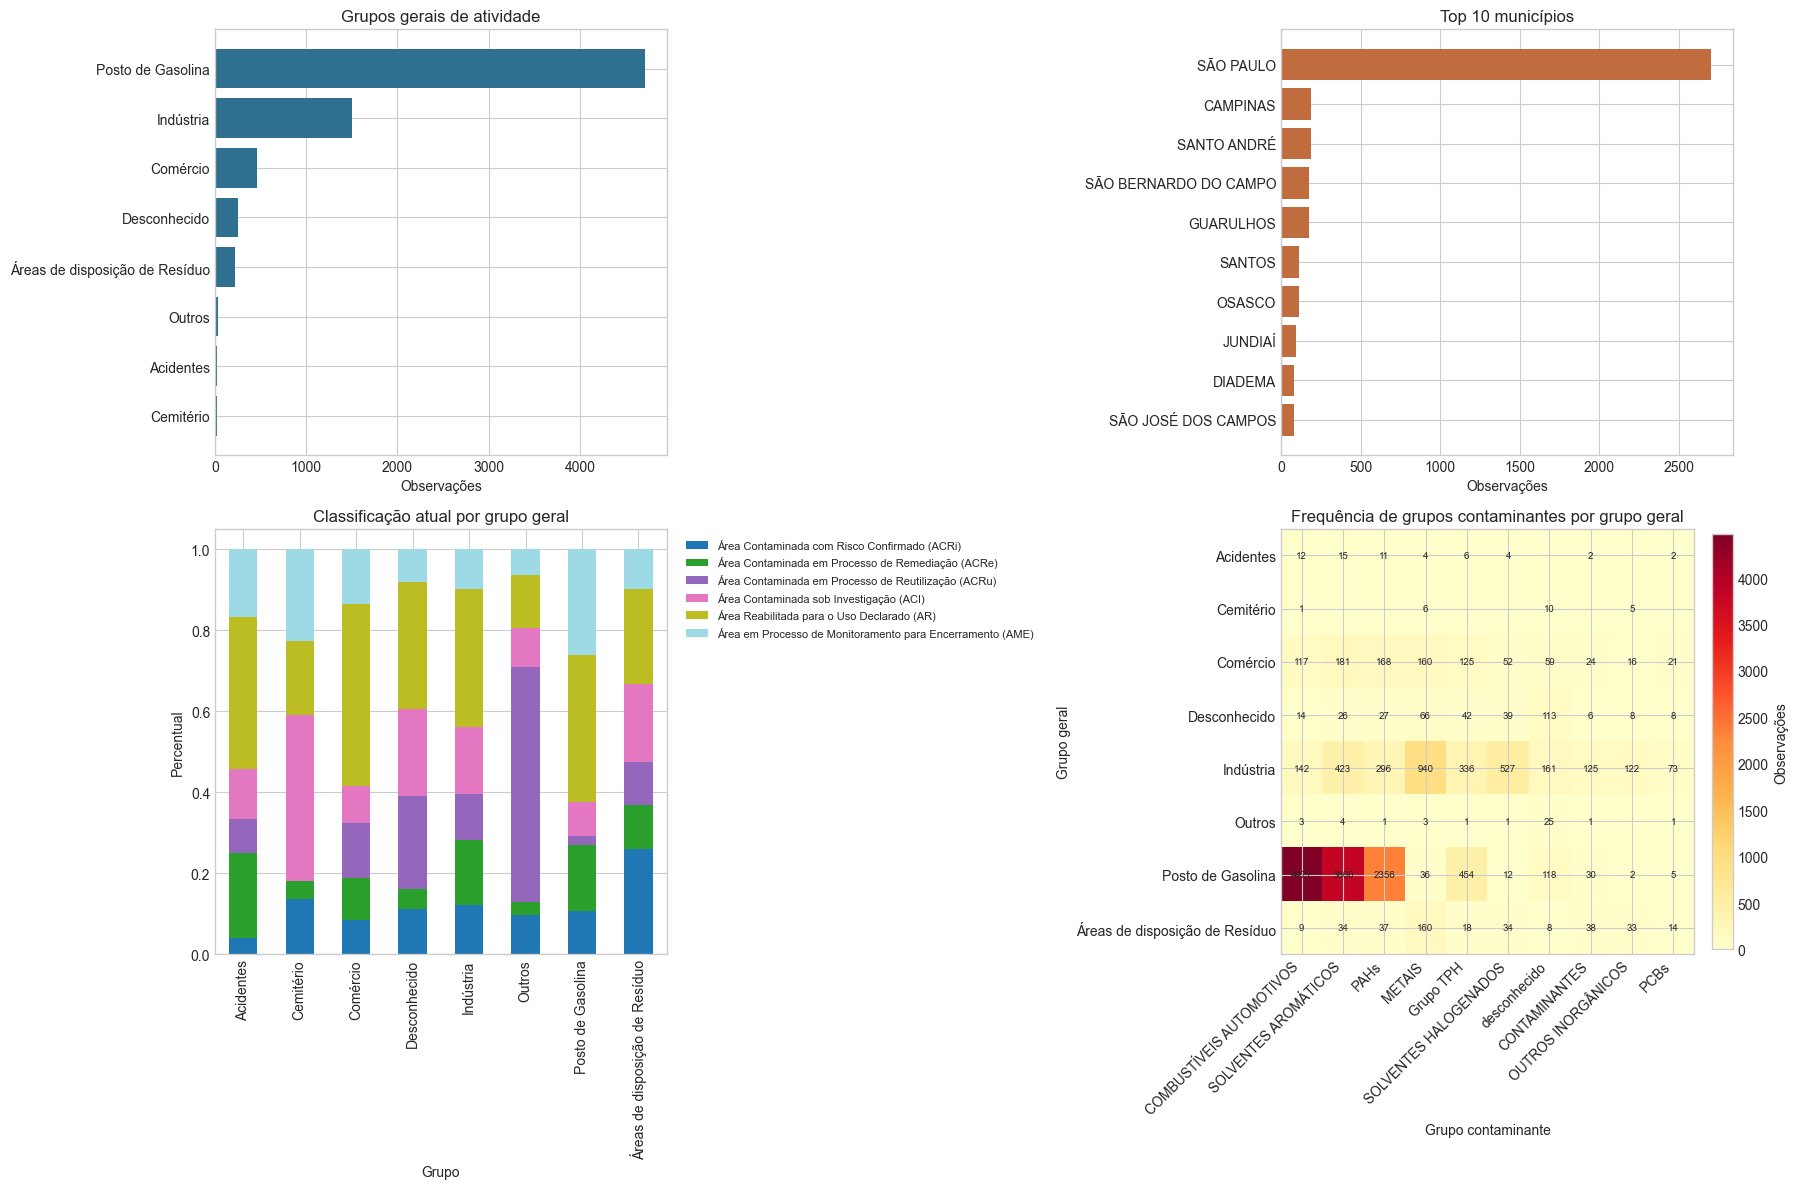

In [7]:
# Cria uma figura com 4 painéis (2 linhas x 2 colunas)
# para resumir diferentes aspectos da base.
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ------------------------------------------------------------
# Painel superior esquerdo: grupos gerais de atividade
# ------------------------------------------------------------

# Seleciona os grupos gerais e ordena do menor para o maior
top_groups = grupo_freq_df.sort_values("qtd_observacoes")

# Plota o gráfico de barras horizontais com a frequência dos grupos gerais.
axes[0, 0].barh(
    top_groups["grupo_atividade_geral"],
    top_groups["qtd_observacoes"],
    color="#2f6f8f"
)
axes[0, 0].set_title("Grupos gerais de atividade")
axes[0, 0].set_xlabel("Observações")

# ------------------------------------------------------------
# Painel superior direito: top 10 municípios
# ------------------------------------------------------------

# Seleciona os 10 municípios com maior número de observações
# e ordena para facilitar a leitura.
top_municipios = municipio_freq_df.head(10).sort_values("qtd_observacoes")

# Plota o gráfico de barras horizontais dos municípios mais frequentes.
axes[0, 1].barh(
    top_municipios["NomMunicipio"],
    top_municipios["qtd_observacoes"],
    color="#c06c3e"
)
axes[0, 1].set_title("Top 10 municípios")
axes[0, 1].set_xlabel("Observações")

# ------------------------------------------------------------
# Painel inferior esquerdo: classificação atual por grupo geral
# ------------------------------------------------------------

# Expande a lista de grupos gerais para que cada grupo fique em uma linha separada,
# depois conta quantas observações existem para cada combinação:
# grupo geral x classificação atual.
group_class_pct_df = (
    areas_analitica
    .explode("grupo_atividade_geral_lista")
    .groupby(["grupo_atividade_geral_lista", "ClassificacaoAtual"])
    .size()
    .unstack(fill_value=0)
)

# Converte as contagens em proporções dentro de cada grupo geral.
# Assim, cada barra empilhada passa a mostrar a composição percentual.
group_class_pct_df = group_class_pct_df.div(group_class_pct_df.sum(axis=1), axis=0)

# Plota as barras empilhadas.
group_class_pct_df.plot(
    kind="bar",
    stacked=True,
    ax=axes[1, 0],
    colormap="tab20"
)
axes[1, 0].set_title("Classificação atual por grupo geral")
axes[1, 0].set_xlabel("Grupo")
axes[1, 0].set_ylabel("Percentual")
axes[1, 0].legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

# ------------------------------------------------------------
# Painel inferior direito: frequência de contaminantes por grupo geral
# ------------------------------------------------------------

# Expande:
# 1. os grupos gerais de atividade
# 2. os grupos contaminantes
#
# Depois disso, cada linha representa uma combinação entre:
# - grupo geral
# - grupo contaminante
group_contaminant_panel_df = (
    areas_analitica
    .explode("grupo_atividade_geral_lista")
    .explode("GrupoContaminante_lista")
    .dropna(subset=["grupo_atividade_geral_lista", "GrupoContaminante_lista"])
    .reset_index(drop=True)
)

# Seleciona os 10 contaminantes mais frequentes da base
# para manter o painel mais legível.
top_contaminants_panel = contaminante_freq_df.head(10)["GrupoContaminante"].tolist()

# Monta uma tabela de frequência:
# linhas   -> grupos gerais
# colunas  -> grupos contaminantes
# valores  -> número de ocorrências
gc_freq_panel_df = (
    group_contaminant_panel_df
    .groupby(["grupo_atividade_geral_lista", "GrupoContaminante_lista"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=top_contaminants_panel, fill_value=0)
)

# Desenha o heatmap usando imshow.
im = axes[1, 1].imshow(gc_freq_panel_df.values, aspect="auto", cmap="YlOrRd")

axes[1, 1].set_title("Frequência de grupos contaminantes por grupo geral")
axes[1, 1].set_xlabel("Grupo contaminante")
axes[1, 1].set_ylabel("Grupo geral")

# Define os rótulos do eixo x com rotação para evitar sobreposição.
axes[1, 1].set_xticks(range(len(gc_freq_panel_df.columns)))
axes[1, 1].set_xticklabels(gc_freq_panel_df.columns, rotation=45, ha="right")

# Define os rótulos do eixo y com os grupos gerais.
axes[1, 1].set_yticks(range(len(gc_freq_panel_df.index)))
axes[1, 1].set_yticklabels(gc_freq_panel_df.index)

# Adiciona os valores dentro de cada célula do heatmap
# para facilitar a leitura direta.
for i in range(gc_freq_panel_df.shape[0]):
    for j in range(gc_freq_panel_df.shape[1]):
        value = int(gc_freq_panel_df.iloc[i, j])
        if value > 0:
            axes[1, 1].text(j, i, value, ha="center", va="center", fontsize=7)

# Adiciona uma barra de cores para indicar a escala de frequência.
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04, label="Observações")

# Ajusta automaticamente o layout para evitar cortes nos elementos.
plt.tight_layout()

# Exibe a figura final.
plt.show()


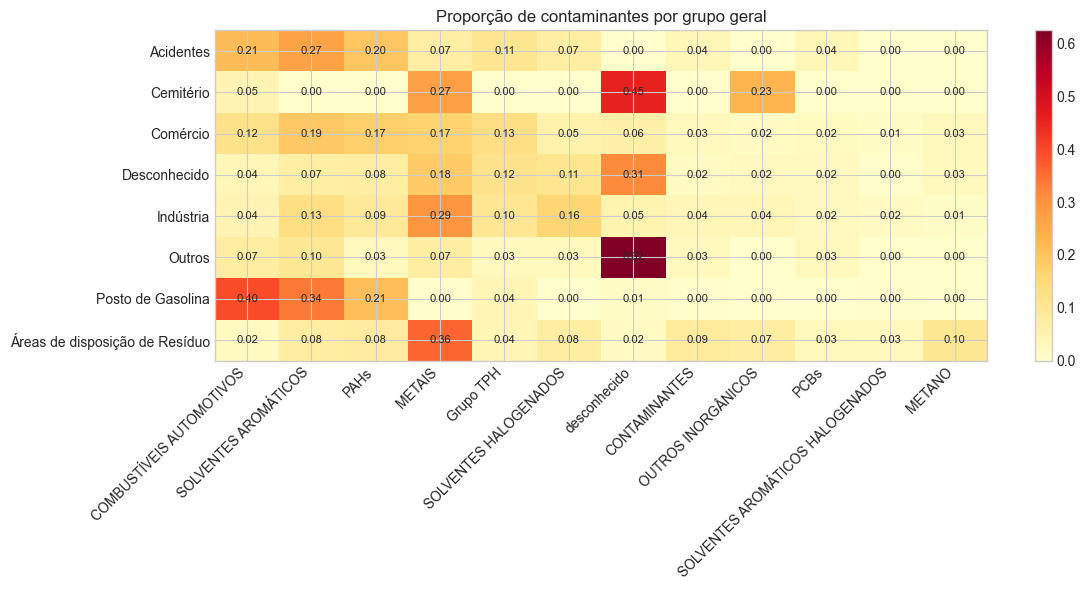

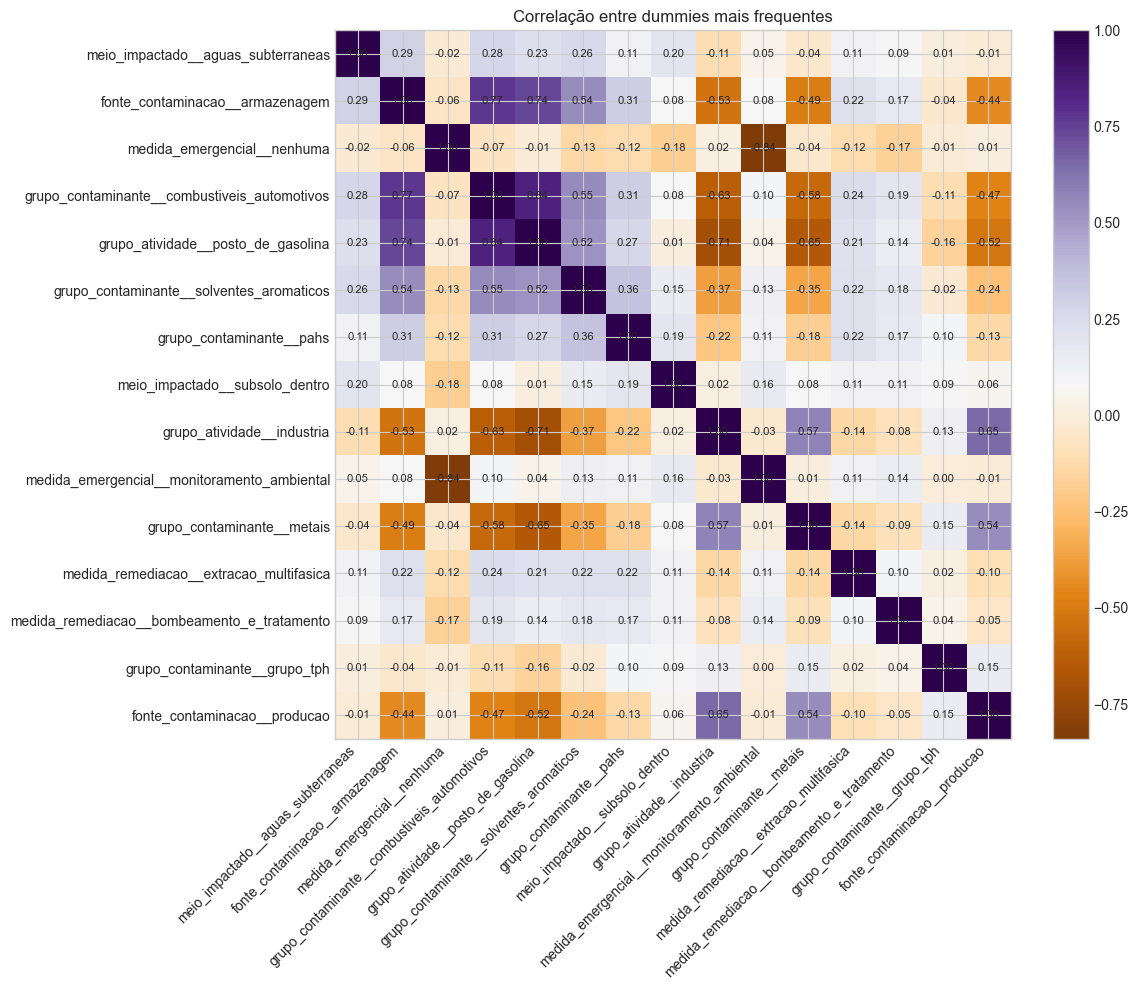

In [8]:
# ------------------------------------------------------------
# 1. Heatmap: proporção de grupos contaminantes por grupo geral
# ------------------------------------------------------------

# Expande as colunas em formato de lista para que cada linha passe
# a representar uma combinação entre:
# - um grupo geral de atividade
# - um grupo contaminante
#
# Exemplo:
# uma observação com
# grupo_atividade_geral_lista = ["Comércio", "Indústria"]
# GrupoContaminante_lista = ["METAIS", "PAHs"]
#
# vira 4 linhas após o double explode.
group_contaminant_df = (
    areas_analitica
    .explode("grupo_atividade_geral_lista")
    .explode("GrupoContaminante_lista")
    .dropna(subset=["grupo_atividade_geral_lista", "GrupoContaminante_lista"])
    .reset_index(drop=True)
)

# Seleciona os 12 grupos contaminantes mais frequentes da base
# para evitar um heatmap muito carregado.
top_contaminants = (
    contaminante_freq_df
    .head(12)["GrupoContaminante"]
    .tolist()
)

# Conta quantas vezes cada contaminante aparece dentro de cada grupo geral.
# O resultado é uma matriz no formato:
# linhas   -> grupos gerais de atividade
# colunas  -> grupos contaminantes
# valores  -> contagem de ocorrências
heatmap_gc_df = (
    group_contaminant_df
    .groupby(["grupo_atividade_geral_lista", "GrupoContaminante_lista"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=top_contaminants, fill_value=0)
)

# Converte as contagens em proporções dentro de cada grupo geral.
# Assim, cada linha soma 1 e pode ser interpretada como composição percentual.
heatmap_gc_df = (
    heatmap_gc_df
    .div(heatmap_gc_df.sum(axis=1), axis=0)
    .fillna(0)
)

# Plota o heatmap de composição dos contaminantes por grupo geral.
plot_heatmap(
    heatmap_gc_df,
    "Proporção de contaminantes por grupo geral",
    figsize=(12, 6),
    cmap="YlOrRd"
)

# ------------------------------------------------------------
# 2. Heatmap: correlação entre as dummies mais frequentes
# ------------------------------------------------------------

# Define os prefixos das colunas dummies que queremos analisar.
# Isso inclui dummies de:
# - grupo geral de atividade
# - grupo contaminante
# - fonte de contaminação
# - meio impactado
# - medida emergencial
# - medida de remediação
dummy_prefixes = (
    "grupo_atividade__",
    "grupo_contaminante__",
    "fonte_contaminacao__",
    "meio_impactado__",
    "medida_emergencial__",
    "medida_remediacao__",
)

# Seleciona apenas as colunas do dataframe de modelagem que são dummies.
dummy_cols = [
    col
    for col in areas_contaminadas_modelagem.columns
    if col.startswith(dummy_prefixes)
]

# Identifica as 15 dummies mais frequentes na base.
# Aqui, a soma da coluna corresponde ao número de observações com valor 1.
top_dummy_cols = (
    areas_contaminadas_modelagem[dummy_cols]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
    .tolist()
)

# Calcula a matriz de correlação entre essas dummies mais frequentes.
# Isso ajuda a entender quais características tendem a aparecer juntas.
dummy_corr_df = (
    areas_contaminadas_modelagem[top_dummy_cols]
    .corr()
    .round(2)
)

# Plota o heatmap da correlação entre as dummies selecionadas.
plot_heatmap(
    dummy_corr_df,
    "Correlação entre dummies mais frequentes",
    figsize=(12, 10),
    cmap="PuOr"
)


In [9]:
# Cria uma cópia apenas com as colunas necessárias para entender
# como o número de linhas cresce após o uso de explode().
# Cada linha ainda representa uma observação original da base.
expansao_df = areas_analitica[
    ["OBJECTID", "grupo_atividade_geral_lista", "GrupoContaminante_lista"]
].copy()

# Conta quantos grupos gerais de atividade existem em cada observação.
# Exemplo: ["Comércio"] -> 1
# Exemplo: ["Comércio", "Indústria"] -> 2
expansao_df["n_grupos_gerais"] = expansao_df["grupo_atividade_geral_lista"].apply(len)

# Conta quantos grupos contaminantes existem em cada observação.
# Exemplo: ["METAIS", "PAHs"] -> 2
expansao_df["n_contaminantes"] = expansao_df["GrupoContaminante_lista"].apply(len)

# Calcula quantas linhas cada observação irá gerar após aplicar:
# .explode("grupo_atividade_geral_lista").explode("GrupoContaminante_lista")
#
# A lógica é:
# número de grupos gerais x número de contaminantes
#
# Exemplo:
# 2 grupos gerais e 3 contaminantes -> 2 * 3 = 6 linhas após o double explode
expansao_df["n_linhas_apos_explode"] = (
    expansao_df["n_grupos_gerais"] * expansao_df["n_contaminantes"]
)

# Mostra quantas linhas existem na base original analisada.
print("Linhas originais:", len(expansao_df))

# Mostra quantas linhas devemos esperar após o double explode,
# somando a contribuição de cada observação.
print(
    "Linhas esperadas após double explode:",
    expansao_df["n_linhas_apos_explode"].sum()
)

# Exibe estatísticas descritivas para entender melhor a distribuição:
# média, mínimo, máximo, quartis etc.
print(
    expansao_df[
        ["n_grupos_gerais", "n_contaminantes", "n_linhas_apos_explode"]
    ].describe()
)


Linhas originais: 7141
Linhas esperadas após double explode: 16873
       n_grupos_gerais  n_contaminantes  n_linhas_apos_explode
count      7141.000000      7141.000000            7141.000000
mean          1.011203         2.343089               2.362834
std           0.111712         1.107742               1.130113
min           1.000000         1.000000               1.000000
25%           1.000000         2.000000               2.000000
50%           1.000000         2.000000               2.000000
75%           1.000000         3.000000               3.000000
max           3.000000        10.000000              10.000000


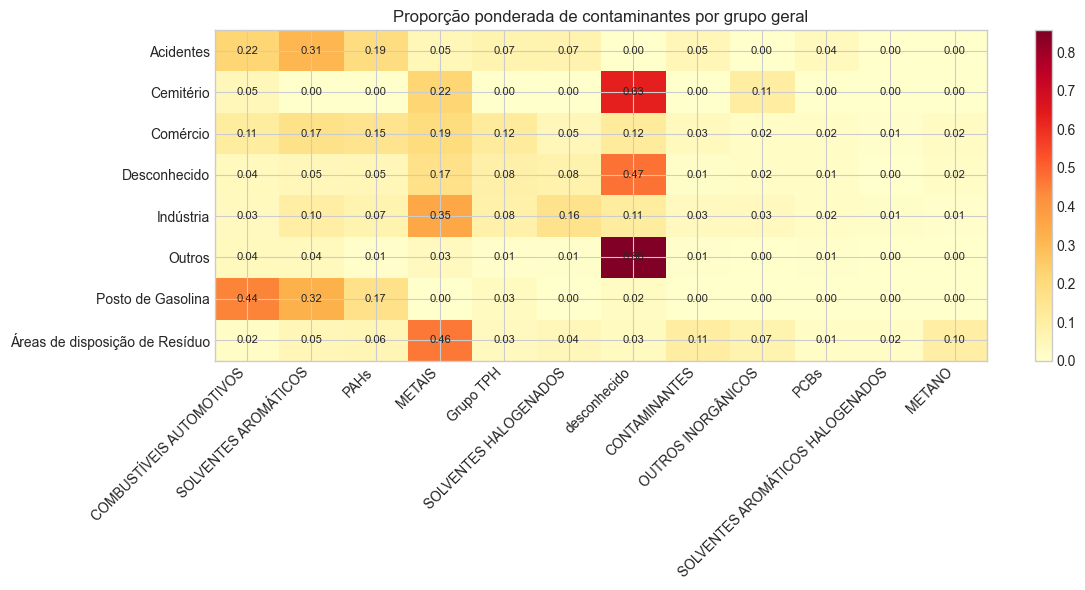

In [10]:
# Seleciona apenas as colunas necessárias para a análise.
# Cada linha ainda representa uma observação original da base.
group_contaminant_df = (
    areas_analitica[["OBJECTID", "grupo_atividade_geral_lista", "GrupoContaminante_lista"]]
    .copy()
)

# Conta quantos grupos gerais de atividade existem em cada observação.
# Na maioria dos casos será 1, mas algumas observações podem pertencer a mais de um grupo.
group_contaminant_df["n_grupos"] = (
    group_contaminant_df["grupo_atividade_geral_lista"].apply(len)
)

# Conta quantos grupos contaminantes existem em cada observação.
# Como uma mesma área pode ter vários contaminantes, esse número costuma ser maior que 1.
group_contaminant_df["n_contaminantes"] = (
    group_contaminant_df["GrupoContaminante_lista"].apply(len)
)

# Define o peso de cada combinação gerada após o explode.
# A ideia é fazer com que cada observação original tenha peso total igual a 1,
# mesmo quando ela for desdobrada em várias combinações grupo x contaminante.
group_contaminant_df["peso"] = 1 / (
    group_contaminant_df["n_grupos"] * group_contaminant_df["n_contaminantes"]
)

# Expande as listas em linhas separadas.
# Depois disso, cada linha passa a representar uma combinação entre:
# - um grupo geral de atividade
# - um grupo contaminante
# associada a um OBJECTID.
group_contaminant_df = (
    group_contaminant_df
    .explode("grupo_atividade_geral_lista")
    .explode("GrupoContaminante_lista")
    .dropna(subset=["grupo_atividade_geral_lista", "GrupoContaminante_lista"])
)

# Seleciona os 12 grupos contaminantes mais frequentes da base
# para manter o heatmap mais legível.
top_contaminants = contaminante_freq_df.head(12)["GrupoContaminante"].tolist()

# Agrupa as combinações por grupo geral e grupo contaminante,
# somando os pesos em vez de contar linhas brutas.
# Isso evita que observações com muitos contaminantes dominem o resultado.
heatmap_gc_df = (
    group_contaminant_df
    .groupby(["grupo_atividade_geral_lista", "GrupoContaminante_lista"])["peso"]
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=top_contaminants, fill_value=0)
)

# Converte os pesos em proporções dentro de cada grupo geral.
# Assim, cada linha do heatmap soma 1 e pode ser interpretada como composição percentual.
heatmap_gc_df = heatmap_gc_df.div(heatmap_gc_df.sum(axis=1), axis=0).fillna(0)

# Plota o heatmap final.
plot_heatmap(
    heatmap_gc_df,
    "Proporção ponderada de contaminantes por grupo geral",
    figsize=(12, 6),
    cmap="YlOrRd"
)
